# CM04 — Small-grain removal and conformal tetrahedral meshing

Uses the same sample and downstream pipeline as CM03. CM03 is unchanged. Run in order in a fresh kernel. Small-grain absorption precedes spike cleaning and upscaling. Existing geometry and quality gates remain mandatory; removal alone is not a mesh-readiness certificate.

## Control guide

These notes describe the existing controls. After changing an upstream setting, rerun its cell and all dependent cells below it. Assignments such as `CAP_MESH_SIZE = GMSH_SIZE` take effect when that cell runs; they are not dynamic links. Physical lengths use the units of `SPACING`. Increasing a limit helps only if that limit is actually preventing progress.

### Input and voxel cleaning

| Control | Meaning; effect of increasing or decreasing |
|---|---|
| `SAMPLE`, `ROOT` | Input data and repository paths. Changing the sample changes the structure. |
| `GRAIN_ID_SEED` | Reproducible random ID/colour permutation. Different integers give different permutations; larger is not necessarily more contrasting. Geometry is unchanged. |
| `CLEAN_SPIKES` | `True` enables UPXO spike removal before refinement; `False` bypasses it. |
| `SPIKE_MAX_PASSES` | Higher allows more cleaning passes; lower stops sooner. No-change and repeated-configuration stops still apply. More passes cannot override protected last voxels. |
| `CLEAN_PINCHES` | Enables targeted voxel contact cleaning; `False` bypasses it. |
| `PINCH_MAX_PASSES` | Higher allows more search passes; lower limits work. Other budgets and acceptance rules still apply. |
| `PINCH_MAX_CHANGES` | Higher allows more accepted voxel reassignments in total; lower is more conservative. |
| `PINCH_MAX_VOLUME_FRACTION` | Higher permits larger per-grain net voxel-count changes; lower preserves counts more tightly. Positive values allow at least one voxel; zero allows none. This is not a displacement limit or total-edit fraction. |
| `PINCH_PROTECT_GRAINS_UP_TO` | Higher protects more small grains from donating voxels; lower permits cleaning smaller grains. Counts are measured after spike cleaning, before upscaling. |
| `UPSCALE_FACTOR` | Integer ≥1: 1 leaves resolution unchanged; higher subdivides along all axes. Memory grows approximately with factor³. Refinement alone preserves the original geometry and contacts; it adds no physical detail. |
| `SPACING` | Original voxel dimensions x/y/z. Increasing a component enlarges that physical dimension; decreasing shrinks it. Use measured spacing, not this setting as a repair control. |

`effective_spacing` is derived from `SPACING / UPSCALE_FACTOR`. Settings using `min(SPACING)` remain tied to original physical voxel size. The pinch detector searches local 2×2×2 face-disconnected arrangements. Its budgets cannot extend detection to every thin neck or later smoothing-induced defect. Accepted edits preserve global six-connected component counts and obey volume/protection rules.

### Surface and junction smoothing

| Control | Increase / decrease effect |
|---|---|
| `LAPLACE_ITERATIONS` | More surface-smoothing steps can reduce staircasing but increase shrinkage, distortion and runtime; fewer retain more voxel detail. Zero disables these steps. |
| `LAPLACE_RELAXATION` | Larger values give stronger averaging steps; smaller are gentler. Use the supported range (0,1]. Local safeguards can suppress movement. |
| `JUNCTION_ITERATIONS` | More steps smooth eligible junction lines further; fewer retain more original shape. Zero disables line smoothing. |
| `JUNCTION_RELAXATION` | Larger values give stronger line-smoothing steps; smaller are gentler. Range (0,1]. |
| `JUNCTION_MAX_DISPLACEMENT` | Larger physical bound permits more total junction movement from extracted geometry; smaller preserves shape more tightly. Extra iterations may do little once constrained. |

Junction endpoints, branches and four-or-more-grain nodes remain frozen, and RVE-plane coordinates stay fixed. Stronger smoothing does not remove these topology constraints and can bring neighbouring sheets closer. Local collapse/reversal safeguards do not certify freedom from global intersections.

### Pre-Gmsh point-contact separation

| Control | Increase / decrease or switch effect |
|---|---|
| `SEPARATE_PINCHES` | Enables splitting disconnected triangle fans at a shared vertex; `False` bypasses it. |
| `PINCH_PRESS_RADIUS` | Larger physical radius affects a broader neighbourhood; smaller localizes pressing near the split tip. |
| `PINCH_PRESS_MAX_DISPLACEMENT` | Larger allows more movement; smaller better preserves shape but may prevent separation. |
| `PINCH_PRESS_ITERATIONS` | More steps permit further adjustment; fewer reduce work and deformation. Constraints still apply. |
| `PINCH_PRESS_RELAXATION` | Larger gives stronger steps; smaller gives gentler adjustment. |
| `PINCH_MIN_OPENING` | Larger demands a wider minimum separation of duplicated tips and can cause rollback if unattainable; smaller accepts narrower separation. It is not a global clearance guarantee. |

Length controls use physical units. This operation handles disconnected point fans: it does **not** cut shared edges or connected multi-grain junctions. Increasing its controls cannot remove contacts outside that scope. Other frozen junction points and RVE coordinates remain constrained.

### Gmsh and RVE caps

| Control | Increase / decrease effect |
|---|---|
| `GMSH_SIZE` | Smaller requests finer surface triangles and greater cost; larger requests coarser triangles. Retained curves and chart seams constrain size. Refinement does not itself remove contacts or overlaps. |
| `GMSH_ALGORITHM` | Categorical: 1 MeshAdapt, 2 Automatic, 5 Delaunay, 6 Frontal-Delaunay. Higher numbers are not inherently better. |
| `CAP_MESH_SIZE` | Smaller requests finer new cap triangles; larger requests coarser ones. |
| `RVE_EDGE_SIZE` | Smaller subdivides new box-edge segments more finely; larger permits longer segments. Existing interface traces remain constrained. |
| `FINAL_GMSH_SIZE` | Same size tradeoff, applied to joint remeshing of internal interfaces and caps. |
| `FINAL_GMSH_ALGORITHM` | Same categorical choices as `GMSH_ALGORITHM`. |

The reported “internal triangle is coplanar with the cap” error is a geometry/classification check. Changing cap size alone does not address that condition. Its investigation and repair are addressed by the CM04 upstream geometry guard.

### Validation, later repairs and tetrahedra

| Control | Increase / decrease or switch effect |
|---|---|
| `MIN_SURFACE_TRIANGLE_QUALITY` | Higher flags more poor triangles; lower accepts more. This is a checking threshold, not an improvement operation. |
| `STOP_ON_VALIDATION_ERRORS` | `True` raises after saving the report; `False` permits later cells but does not make failed geometry valid. |
| `REPAIR_CONTACTS` | Enables the later contact repair; `False` bypasses it. |
| `REPAIR_SEPARATION` | Larger physical movement limit permits stronger separation; smaller is more conservative. Only supported ambiguous edges/fans are handled; genuine multi-grain junction edges remain shared. |
| `REPAIR_INTERFACE_CROSSINGS` | Enables the supported local crossing repair; `False` bypasses it. |
| `CROSSING_MAX_DISPLACEMENT` | Larger permits larger physical corrections; smaller can reject required movement. |
| `CROSSING_NEIGHBOURHOOD_RADIUS` | Larger uses a broader region to estimate separation directions; smaller uses more local normals. It is not a general collision-search distance. |
| `CROSSING_OPENING` | Larger dimensionless value requests wider wedge separation relative to distance from the junction line; smaller is gentler. Excessive opening can violate movement or inversion checks. |
| `RUN_TET_VERIFICATION` | Enables actual tetrahedral generation and checks. Disabling it does not establish readiness. |
| `TET_MESH_SIZE` | Smaller requests finer volume elements at greater cost; larger requests coarser ones, subject to surface constraints. Neither direction guarantees better minimum quality. |
| `TET_OPTIMIZE_NETGEN` | Enables optimization, retaining the baseline for a volume when its minimum quality worsens. |
| `MIN_TET_QUALITY` | Higher makes acceptance stricter; lower admits worse tetrahedra. It does not itself improve elements. |

Crossing repair supports particular interface wedges beside shared junction lines, not arbitrary overlaps or coplanar triangles. Revalidation is required after repairs.

### Display and output controls

| Control | Effect |
|---|---|
| `GRAIN_ID` | `None` shows all interfaces; a shuffled ID selects that grain's interfaces. |
| `AUDIT_ORIGINAL_GRAIN_ID` | Original unshuffled ID to trace; `None` selects a smallest input grain. |
| `OPACITY`, `CAP_OPACITY` | Higher is more opaque; lower more transparent (0–1). Transparency can complicate interpretation. |
| `SHOW_EDGES`, `SHOW_JUNCTION_LINES`, `SHOW_AUDIT_GRAIN`, `GMSH_SHOW_CURVES`, `SHOW_INTERNAL_INTERFACES`, `CAP_SHOW_EDGES`, `FINAL_SHOW_INTERNAL`, `PLOT_VALIDATION_ISSUES`, `SHOW_REPAIRED_SURFACES`, `SHOW_TET_CRINKLE_CLIP` | Display switches only: `True` shows the feature, `False` hides it. Gmsh curves can include computational seams. Crinkle clipping displays whole intersected tetrahedra. |
| `GMSH_VERBOSE` | Enables detailed Gmsh messages; no intended geometry change. |
| Names ending in `_OUTPUT` or `_AUDIT` | Saved-file locations, not numerical controls. |

**CM04 repair scope:** contact/overlap diagnosis, more rigorous voxel cleaning and the RVE coplanarity error are authorized for CM04. The CM04 stages below implement bounded repairs and report unresolved defects. Images alone cannot establish every shared-node contact or triangle intersection.


In [1]:
from pathlib import Path
import sys
import importlib
import numpy as np

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/upxo/meshing/gbconformant').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Start Jupyter inside the upxo_library checkout.')
sys.path.insert(0, str(ROOT / 'src'))
from upxo.meshing.gbconformant.d3v2p0.paths import data_directory
DATA_ROOT = data_directory()
RUN_DIR = DATA_ROOT / 'runs' / 'CM04'
RUN_DIR.mkdir(parents=True, exist_ok=True)
# Refresh shared helpers as well as entry points in an existing kernel.
for _name in ('facet_angles', 'surface_intersections', 'surface_charts', 'discrete_topology'):
    importlib.reload(importlib.import_module('upxo.meshing.gbconformant.d3v2p0.' + _name))
interface_module = importlib.reload(importlib.import_module('upxo.meshing.gbconformant.d3v2p0.interfaces'))
smooth_interfaces = interface_module.smooth_interfaces
SAMPLE = DATA_ROOT / 'samples/lgi_twinned_clean.npy'
labels_original = np.load(SAMPLE, allow_pickle=False)

GRAIN_ID_SEED = 42
original_grain_ids = np.unique(labels_original)
shuffled_grain_ids = np.random.default_rng(GRAIN_ID_SEED).permutation(original_grain_ids)
grain_id_map = dict(zip(original_grain_ids.tolist(), shuffled_grain_ids.tolist()))
labels = shuffled_grain_ids[np.searchsorted(original_grain_ids, labels_original)]
print(f'{labels.shape}: {len(original_grain_ids)} grains')
import json
SPACING = (1., 1., 1.)


(51, 51, 51): 587 grains


## Optional small-grain removal

`REMOVE_SMALL_GRAINS`: bypass when False. `MIN_GRAIN_VOXELS`: remove candidates strictly smaller than this count **before upscaling**; increasing it considers more grains. Start conservatively at 4. Unsafe candidates remain and are reported.

`PROTECTED_GRAIN_IDS`: shuffled IDs that must survive (they may receive voxels). `PROTECT_RVE_GRAINS`: also protect IDs touching any RVE face. Protect scientifically important islands explicitly. `REMOVAL_MAX_PASSES`: more passes allow revisiting candidates after neighbouring merges. `RECIPIENT_SELECTION`: `shared_area` prefers the largest face-contact area; `largest` prefers the largest neighbouring grain. Ties use grain ID. Spacing from the loading cell weights contact areas.

New cubical boundary-link defects and changes in recipient component count are rejected. Existing input defects still require downstream repair. Whole IDs, including disconnected pieces, are considered together. Surviving IDs are never renumbered. The report includes rejected candidates, mappings and volume changes. This first implementation uses full-grid checks and prioritizes correctness over speed.

In [2]:
REMOVE_SMALL_GRAINS = True
MIN_GRAIN_VOXELS = 4
PROTECTED_GRAIN_IDS = []
PROTECT_RVE_GRAINS = False
REMOVAL_MAX_PASSES = 10
RECIPIENT_SELECTION = 'shared_area'

_small = importlib.reload(importlib.import_module('upxo.meshing.gbconformant.d3v2p0.small_grains'))
labels_reduced, removal_report = _small.remove_small_grains(
    labels, enabled=REMOVE_SMALL_GRAINS, min_voxels=MIN_GRAIN_VOXELS,
    protected_ids=PROTECTED_GRAIN_IDS, protect_rve=PROTECT_RVE_GRAINS,
    max_passes=REMOVAL_MAX_PASSES, selection=RECIPIENT_SELECTION, spacing=SPACING)
retained_grain_ids = np.unique(labels_reduced)
original_to_retained = {int(g): removal_report['original_to_survivor'][int(s)]
                       for g, s in grain_id_map.items()}
REMOVAL_AUDIT = RUN_DIR / 'CM04_small_grains.json'
REMOVAL_AUDIT.parent.mkdir(parents=True, exist_ok=True)
REMOVAL_AUDIT.write_text(json.dumps(dict(report=removal_report,
    original_to_retained=original_to_retained), indent=2))
print('Grains:', len(np.unique(labels)), '->', len(retained_grain_ids))
print('Removed IDs:', removal_report['removed_ids'])
print('Unresolved small IDs:', removal_report['unresolved_small_ids'])
print('Boundary defects:', removal_report['initial_defects'], '->', removal_report['remaining_defects'])


Grains: 587 -> 516
Removed IDs: [2, 8, 22, 31, 45, 50, 51, 60, 67, 78, 105, 116, 126, 135, 142, 152, 157, 174, 182, 193, 203, 211, 227, 231, 250, 255, 262, 268, 281, 292, 304, 307, 308, 313, 318, 325, 327, 330, 332, 352, 357, 358, 397, 403, 413, 421, 427, 438, 466, 468, 469, 478, 481, 497, 513, 515, 524, 532, 533, 551, 553, 559, 567, 584, 587, 589, 594, 602, 618, 625, 627]
Unresolved small IDs: []
Boundary defects: 321 -> 321


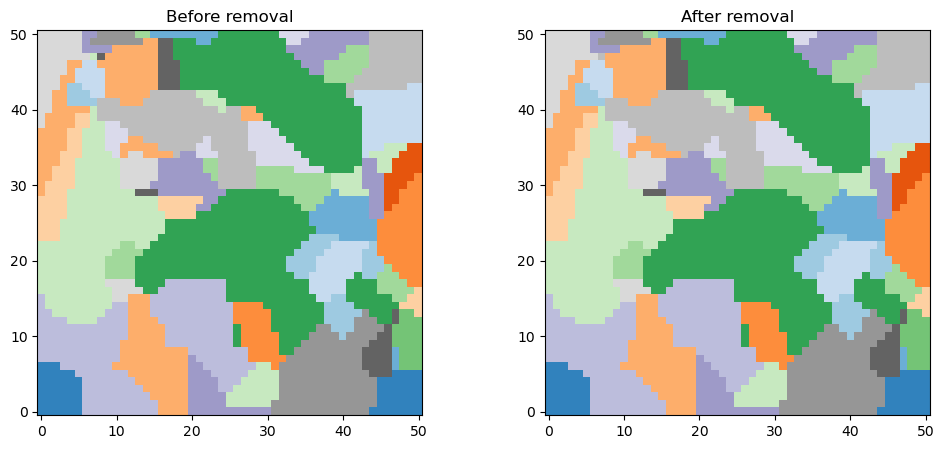

In [3]:
# Before/after voxel sections with the same colour scale.
import matplotlib.pyplot as plt
VOXEL_CMAP = 'tab20c'
SLICE_Z = labels.shape[2] // 2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in zip(axes, (labels, labels_reduced), ('Before removal', 'After removal')):
    ax.imshow(data[:, :, SLICE_Z].T, origin='lower', cmap=VOXEL_CMAP,
              vmin=labels.min(), vmax=labels.max(), interpolation='nearest')
    ax.set_title(title)
plt.show()


## Iterative UPXO spike removal before upscaling
Uses the existing `StructureCleaner3D._fast_clean_spikes` routine from `upxo.pxtal.twinned_simple_3d.cleaning_3d`. A spike has at most one face-connected neighbor with the same grain ID. Each pass reassigns spikes to neighboring grains while protecting the last voxel of every grain.

Set `CLEAN_SPIKES = False` to bypass cleaning, or adjust `SPIKE_MAX_PASSES`. Cleaning stops when a pass changes no voxels, the pass limit is reached, or a label configuration repeats. Remaining spike candidates can include protected singleton grains. Cleaning changes grain shapes and voxel counts; the original `labels` and input file remain intact. The optional pinch-cleaning step receives `labels_cleaned` before upscaling.


In [4]:
CLEAN_SPIKES = True
SPIKE_MAX_PASSES = 100

# Always start from loaded/shuffled labels, not the result of a previous run.
labels_cleaned = labels_reduced.copy()
spike_history = []
spike_stop_reason = 'disabled'
if CLEAN_SPIKES:
    import hashlib
    from upxo.pxtal.twinned_simple_3d.cleaning_3d import StructureCleaner3D

    if isinstance(SPIKE_MAX_PASSES, bool) or not isinstance(SPIKE_MAX_PASSES, (int, np.integer)) or SPIKE_MAX_PASSES < 1:
        raise ValueError('SPIKE_MAX_PASSES must be a positive integer')
    if np.any(labels_cleaned < 0):
        raise ValueError('The UPXO spike cleaner requires nonnegative labels.')
    spike_cleaner = StructureCleaner3D(upscale_fallback=False, do_lobe_split=False)
    grain_ids_before_cleaning = np.unique(labels_cleaned)
    seen_states = {hashlib.sha256(labels_cleaned.tobytes()).digest()}
    spike_stop_reason = 'maximum passes reached'
    for pass_number in range(1, SPIKE_MAX_PASSES + 1):
        labels_cleaned, changed = spike_cleaner._fast_clean_spikes(labels_cleaned)
        spike_history.append({'pass': pass_number, 'changed_voxels': int(changed)})
        print(f'Spike pass {pass_number}: {changed} voxels reassigned')
        if changed == 0:
            spike_stop_reason = 'no further changes'
            break
        state = hashlib.sha256(labels_cleaned.tobytes()).digest()
        if state in seen_states:
            spike_stop_reason = 'repeated label configuration'
            break
        seen_states.add(state)
    assert np.array_equal(np.unique(labels_cleaned), grain_ids_before_cleaning), 'Cleaning lost a grain ID'
    remaining_candidates = np.count_nonzero(
        (labels_cleaned > 0) & (spike_cleaner._count_face_same_grain(labels_cleaned)
                               <= spike_cleaner._SPIKE_SAME_COUNT_THRESHOLD))
    print(f'Remaining spike candidates (including protected last voxels): {remaining_candidates}')
print('Spike cleaning stopped:', spike_stop_reason)
print('Net changed voxels:', np.count_nonzero(labels_cleaned != labels))
print('Grains retained:', len(np.unique(labels_cleaned)))


Spike pass 1: 31 voxels reassigned
Spike pass 2: 24 voxels reassigned
Spike pass 3: 23 voxels reassigned
Spike pass 4: 22 voxels reassigned
Spike pass 5: 22 voxels reassigned
Remaining spike candidates (including protected last voxels): 22
Spike cleaning stopped: repeated label configuration
Net changed voxels: 103
Grains retained: 516


## Optional targeted voxel pinch cleaning
Run after spike removal and before upscaling. `CLEAN_PINCHES` turns the step on or off. The detector searches 2 x 2 x 2 blocks for same-grain voxels connected only through edges/corners locally. It does not apply a majority filter. These are candidates, not proof that the contact is physically wrong; thin necks and pinches introduced later by smoothing are outside this detector's scope.

Each accepted one-voxel edit must remove candidates without introducing new ones, retain every grain ID, and preserve each grain's global face-connected component count. This does not guarantee preservation of tunnels, cavities, or all grain adjacency relationships. Small grains cannot donate voxels. Per-grain net volume change is limited to the greater of one voxel and the specified fraction of its initial count; a zero fraction forbids volume changes.

Controls cap passes, accepted edits, volume change and small-grain protection. Unresolved candidates remain reported. The input `labels_cleaned` remains unchanged; `labels_pinch_cleaned` feeds upscaling. The JSON audit records every voxel reassignment for inspection or replay. Compare on/off results with identical smoothing and Gmsh settings.


In [5]:
CLEAN_PINCHES = True  # False bypasses this step completely.
PINCH_MAX_PASSES = 100
PINCH_MAX_CHANGES = 200
PINCH_MAX_VOLUME_FRACTION = 0.03
PINCH_PROTECT_GRAINS_UP_TO = 8  # Original voxel count, after spike cleaning.

import json
_pinch_module = importlib.reload(importlib.import_module('upxo.meshing.gbconformant.d3v2p0.pinch_cleaning'))
labels_pinch_cleaned, pinch_report, pinch_changes = _pinch_module.clean_pinch_contacts(
    labels_cleaned, enabled=CLEAN_PINCHES,
    max_passes=PINCH_MAX_PASSES, max_changes=PINCH_MAX_CHANGES,
    max_volume_fraction=PINCH_MAX_VOLUME_FRACTION,
    protect_grains_up_to=PINCH_PROTECT_GRAINS_UP_TO)
print(json.dumps(pinch_report, indent=2))
PINCH_AUDIT = RUN_DIR / 'CM04_pinch_cleaning.json'
PINCH_AUDIT.parent.mkdir(parents=True, exist_ok=True)
PINCH_AUDIT.write_text(json.dumps({'report': pinch_report, 'changes': pinch_changes}, indent=2))
print('Pinch-cleaning audit:', PINCH_AUDIT)


{
  "enabled": true,
  "initial_candidates": 107,
  "remaining_candidates": 0,
  "accepted_changes": 104,
  "net_changed_voxels": 104,
  "grains_retained": 516,
  "face_component_counts_preserved": true,
  "stop_reason": "no candidates remain",
  "passes": [
    {
      "pass": 1,
      "accepted": 104,
      "remaining_candidates": 0
    }
  ],
  "grain_voxel_changes": {
    "3": -1,
    "4": -1,
    "7": 1,
    "15": -3,
    "20": -1,
    "32": -3,
    "36": -1,
    "44": 3,
    "53": 1,
    "64": 3,
    "68": -2,
    "82": -1,
    "84": 1,
    "100": -2,
    "101": 1,
    "104": 1,
    "106": 1,
    "111": 1,
    "123": -2,
    "130": -1,
    "150": 1,
    "167": -1,
    "169": 1,
    "185": 1,
    "196": 1,
    "204": 5,
    "205": -1,
    "208": 1,
    "235": 2,
    "239": 3,
    "241": -1,
    "243": -1,
    "247": 2,
    "252": -1,
    "260": 2,
    "263": 1,
    "266": -1,
    "267": -2,
    "270": -1,
    "271": -1,
    "275": -2,
    "282": -1,
    "296": -1,
    "301": -2,
 

### Rigorous voxel boundary topology cleaning

This checks whether every grain has a single, non-branching boundary link at each lattice vertex, including RVE faces, edges and corners. It detects point contacts, alternating edge contacts and disconnected complementary regions. Single-voxel edits and bounded two-voxel edits reduce the defect count; every grain ID is retained. This is targeted topology cleaning, not a majority filter.

Higher pass/change/pair-trial budgets allow more search. A higher volume fraction permits larger **net** per-grain count changes; zero still permits count-preserving swaps. Raising the small-grain protection threshold protects more donors. `TOPOLOGY_PRESERVE_COMPONENTS=False` permits changes to connected-component counts, including removal of legitimate contacts; set True to restrict them. `REQUIRE_CLEAN_TOPOLOGY` stops on remaining defects. The audit records all edits and unresolved vertices. All switches are user-controlled.

A positive volume fraction allows at least one voxel of net count change per grain; this discrete minimum can exceed that fraction for very small grains. Zero allows only count-preserving swaps. Set `TOPOLOGY_MAX_PAIR_TRIALS=0` to disable two-voxel lookahead.


In [6]:
# Exact cubical boundary-link cleaning, including RVE boundary vertices.
CLEAN_VOXEL_TOPOLOGY = True
TOPOLOGY_MAX_PASSES = 20
TOPOLOGY_MAX_CHANGES = 5000
TOPOLOGY_MAX_VOLUME_FRACTION = 0.20
TOPOLOGY_PROTECT_GRAINS_UP_TO = 0
TOPOLOGY_PRESERVE_COMPONENTS = False
TOPOLOGY_MAX_PAIR_TRIALS = 20000
REQUIRE_CLEAN_TOPOLOGY = True

_topology = importlib.reload(importlib.import_module('upxo.meshing.gbconformant.d3v2p0.voxel_topology'))
labels_meshing, topology_report, topology_changes = _topology.clean_voxel_topology(
    labels_pinch_cleaned, enabled=CLEAN_VOXEL_TOPOLOGY,
    max_passes=TOPOLOGY_MAX_PASSES, max_changes=TOPOLOGY_MAX_CHANGES,
    max_volume_fraction=TOPOLOGY_MAX_VOLUME_FRACTION,
    protect_grains_up_to=TOPOLOGY_PROTECT_GRAINS_UP_TO,
    preserve_components=TOPOLOGY_PRESERVE_COMPONENTS,
    max_pair_trials=TOPOLOGY_MAX_PAIR_TRIALS)
TOPOLOGY_AUDIT = RUN_DIR / 'CM04_voxel_topology.json'
TOPOLOGY_AUDIT.parent.mkdir(parents=True, exist_ok=True)
TOPOLOGY_AUDIT.write_text(json.dumps({'report': topology_report, 'changes': topology_changes}, indent=2))
print({k:v for k,v in topology_report.items() if k not in ('unresolved', 'grain_voxel_changes')})
assert np.array_equal(np.unique(labels_meshing), retained_grain_ids)
if REQUIRE_CLEAN_TOPOLOGY and topology_report['remaining_defects']:
    raise RuntimeError('Unresolved voxel boundary defects: inspect TOPOLOGY_AUDIT before continuing.')


{'enabled': True, 'initial_defects': 131, 'remaining_defects': 0, 'accepted_changes': 120, 'net_changed_voxels': 120, 'all_grain_ids_preserved': True, 'preserve_components': False, 'stop_reason': 'no defects remain', 'passes': [{'pass_number': 1, 'accepted': 115, 'remaining': 3}, {'pass_number': 2, 'accepted': 1, 'remaining': 2}, {'pass_number': 3, 'accepted': 2, 'remaining': 1}, {'pass_number': 4, 'accepted': 2, 'remaining': 0}], 'pair_trials': 23}


## Optional resolution increase before smoothing
Set `UPSCALE_FACTOR` to an integer: `1` leaves the data unchanged, `2` doubles the resolution along each axis, and `3` triples it. Each original voxel is subdivided into identically labelled voxels using nearest-neighbor replication; no new grain IDs are introduced. Spacing decreases by the same factor, preserving physical RVE dimensions and grain shapes before smoothing.

For the current 50 x 50 x 50 sample, factor 2 produces 100 x 100 x 100 voxels; factor 3 produces 150 x 150 x 150. This notebook limits refinement to a maximum factor of 3. Voxel memory grows as factor cubed, and interface triangle count as factor squared. At higher resolution, the same Laplacian iteration count generally smooths over a smaller physical distance; increase `LAPLACE_ITERATIONS` if needed. Always refine from `labels_meshing`, so rerunning this cell does not compound the upscaling.


In [7]:
UPSCALE_FACTOR = 2  # 1: unchanged; 2 or 3: subdivide along all three axes.
if UPSCALE_FACTOR not in (1, 2, 3):
    raise ValueError("CM04 supports upscale factors 1, 2, or 3 (maximum).")
# SPACING is set in the loading cell; original value = (1.0, 1.0, 1.0)  # Original voxel spacing, before refinement.

# Refresh definitions if the notebook kernel predates this module update.
interface_module = importlib.reload(importlib.import_module('upxo.meshing.gbconformant.d3v2p0.interfaces'))
smooth_interfaces = interface_module.smooth_interfaces
labels_upscaled, effective_spacing = interface_module.upscale_labels(
    labels_meshing, factor=UPSCALE_FACTOR, spacing=SPACING)
print(f'Voxel shape: {labels_meshing.shape} -> {labels_upscaled.shape}')
print(f'Effective voxel spacing: {effective_spacing}')
print(f'Physical RVE dimensions: {np.array(labels_upscaled.shape) * effective_spacing}')


Voxel shape: (51, 51, 51) -> (102, 102, 102)
Effective voxel spacing: [0.5 0.5 0.5]
Physical RVE dimensions: [51. 51. 51.]


## Extract and smooth interfaces only
Change the iteration count and relaxation to control smoothing. Shared interfaces are extracted once per adjacent grain pair. Surface triangles are used for rendering; there is no volume meshing step.

Junction edges are identified from their incident grain interfaces, avoiding false branches caused by surface triangulation diagonals. Genuine junction points (four or more grains), branches and endpoints remain fixed. Movable degree-two junction nodes have independent controls:

- `JUNCTION_ITERATIONS`: line-smoothing steps; 0 disables line motion.
- `JUNCTION_RELAXATION`: smoothing rate; 0.25 is a damped starting value.
- `JUNCTION_MAX_DISPLACEMENT`: maximum total movement from the extracted coordinates, in physical units. The default uses 0.75 original voxel widths, independently of upscaling.

Surface smoothing and line smoothing advance together until their respective iteration limits. Triangle-collapse checks can restrict individual moves; frozen endpoints and branches can retain sharp turns. Increase surface iterations if surrounding surfaces constrain line motion. Turning-angle diagnostics refer only to movable degree-two nodes (0 degrees is straight).


In [8]:
LAPLACE_ITERATIONS = 50
LAPLACE_RELAXATION = 0.75

# Independent controls for actual junction-line edges.
JUNCTION_ITERATIONS = 10
JUNCTION_RELAXATION = 0.35  # Damped Laplacian step; 0 < value <= 1.
JUNCTION_MAX_DISPLACEMENT = 0.75 * min(SPACING)  # Physical units, from extracted geometry.

# Refresh the function even when only this cell is rerun after a source edit.
interface_module = importlib.reload(importlib.import_module('upxo.meshing.gbconformant.d3v2p0.interfaces'))
smooth_interfaces = interface_module.smooth_interfaces
interfaces = smooth_interfaces(labels_upscaled, spacing=effective_spacing,
                               iterations=LAPLACE_ITERATIONS,
                               relaxation=LAPLACE_RELAXATION,
                               junction_iterations=JUNCTION_ITERATIONS,
                               junction_relaxation=JUNCTION_RELAXATION,
                               junction_max_displacement=JUNCTION_MAX_DISPLACEMENT)
assert np.array_equal(interfaces.points[interfaces.node_kind == 3],
                      interfaces.original_points[interfaces.node_kind == 3])
assert np.array_equal(interfaces.points[interfaces.fixed_axes],
                      interfaces.original_points[interfaces.fixed_axes])
print(f'{len(interfaces.points):,} surface nodes; {len(interfaces.triangles):,} interface triangles')
print(f'Accepted Laplacian iterations: {interfaces.accepted_iterations}')
print('Frozen junction points:', np.count_nonzero(interfaces.node_kind == 3))
import json
print(json.dumps(interfaces.junction_metrics(), indent=2))

# Stable input for rerunning the optional point-contact separation cell.
interfaces_smoothed = interfaces


258,516 surface nodes; 543,112 interface triangles
Accepted Laplacian iterations: 50
Frozen junction points: 3700
{
  "movable_nodes": 29901,
  "junction_edges": 35368,
  "mean_turn_before_deg": 29.05789104043343,
  "mean_turn_after_deg": 10.08259094663184,
  "turns_over_45_before": 9654,
  "turns_over_45_after": 10,
  "maximum_line_displacement": 0.522877498271693
}


### Check and stabilize smoothed geometry before Gmsh

Smoothing can introduce intersections even when voxel topology is valid. The guard checks triangle intersections, source-relative collapse/reversal and approach to RVE planes. Affected nodes and one neighbour ring are pulled back toward extracted voxel coordinates. Frozen junctions and existing RVE coordinates stay fixed. Local staircase detail may return where required; no triangles or grains are deleted.

Larger clearance keeps originally interior nodes farther from box planes (capped by their original distance). More passes permit more repair attempts. `GEOMETRY_ROLLBACK_RELAXATION` is the retained fraction of smoothing displacement per retry: **smaller values restore voxel detail more strongly**, larger values more gradually. A finite maximum correction bounds movement in physical units; None permits complete rollback. Disabled mode reports unverified geometry. A failed enabled repair raises.

The Gmsh cell additionally checks intersections/cap tangencies. Its bounded retries restore the source triangulation on affected charts, limiting geometric approximation there. These checks do not replace later closed-volume and tetrahedral-quality validation.


**Near-contact opening:** `MIN_FACET_OPENING_DEGREES` rejects almost closed wedges between triangles sharing an edge, including triple lines. Increasing it restores more local voxel detail and limits near-singular sheets; decreasing it permits sharper wedges. `0` disables this check. The default is 1 degree; Gmsh can reject angles below its 0.1 degree overlap tolerance even when there is no mathematical intersection. This control is checked before and after Gmsh and during quality repair. Frozen junction points and RVE-plane coordinates remain fixed.


In [9]:
# Restore local voxel detail where smoothing creates invalid geometry.
GUARD_SMOOTHED_GEOMETRY = True
MIN_FACET_OPENING_DEGREES = 1.0  # 0 disables; Gmsh rejects nearly closed wedges
GEOMETRY_BOUNDARY_CLEARANCE = 0.05 * float(np.min(effective_spacing))
GEOMETRY_MAX_PASSES = 100
GEOMETRY_ROLLBACK_RELAXATION = 0.5
GEOMETRY_MAX_CORRECTION = None  # None permits return to original voxel geometry.

_guard = importlib.reload(importlib.import_module('upxo.meshing.gbconformant.d3v2p0.geometry_guard'))
interfaces, geometry_report = _guard.stabilize_interfaces(
    interfaces_smoothed, np.array(labels_upscaled.shape) * effective_spacing,
    enabled=GUARD_SMOOTHED_GEOMETRY, boundary_clearance=GEOMETRY_BOUNDARY_CLEARANCE,
    max_passes=GEOMETRY_MAX_PASSES, relaxation=GEOMETRY_ROLLBACK_RELAXATION,
    max_correction=GEOMETRY_MAX_CORRECTION,
    minimum_facet_angle=MIN_FACET_OPENING_DEGREES)
GEOMETRY_AUDIT = RUN_DIR / 'CM04_geometry_guard.json'
GEOMETRY_AUDIT.write_text(json.dumps(geometry_report, indent=2))
print(json.dumps(geometry_report, indent=2))
interfaces_before_unpinch = interfaces


{
  "enabled": true,
  "verified": true,
  "remaining_intersections": 0,
  "moved_nodes": 9201,
  "maximum_correction": 1.4202965732922592,
  "boundary_clearance": 0.025,
  "history": [
    {
      "pass_number": 0,
      "intersections": 72,
      "small_facet_angles": 15,
      "affected_nodes": 1740
    },
    {
      "pass_number": 1,
      "intersections": 128,
      "small_facet_angles": 2,
      "affected_nodes": 1490
    },
    {
      "pass_number": 2,
      "intersections": 14,
      "small_facet_angles": 0,
      "affected_nodes": 356
    },
    {
      "pass_number": 3,
      "intersections": 3,
      "small_facet_angles": 0,
      "affected_nodes": 86
    },
    {
      "pass_number": 4,
      "intersections": 0,
      "small_facet_angles": 0,
      "affected_nodes": 28
    },
    {
      "pass_number": 5,
      "intersections": 0,
      "small_facet_angles": 0,
      "affected_nodes": 10
    },
    {
      "pass_number": 6,
      "intersections": 0,
      "small_facet_ang

## Separate point contacts and press down their tips before Gmsh
This optional step intentionally removes even legitimate point contacts when the incident triangles form disconnected surface fans. Each fan receives its own node and its tip is relaxed inward with a smoothly decaying influence over the surrounding surface. Topology can change, and grain volumes are not preserved.

`SEPARATE_PINCHES` turns this on/off. Radius, maximum movement, and minimum opening are in physical units; the defaults scale with the original voxel spacing, independently of upscaling. Only the nodes at selected contacts are released from their former common-node/frozen constraints. Other frozen junction points remain fixed, and RVE coordinates stay on their original planes.

The step preserves edge incidence, guards against triangle collapse and per-step reversal, and rolls back the batch if any duplicated tips cannot be opened sufficiently. Connected surface fans and shared junction edges are not cut; separating those would require reconstructing interface patches. It does not certify the absence of global intersections or produce a tetrahedral mesh.

Rerun the smoothing cell once to populate `interfaces_before_unpinch`. After that, this cell can be rerun with different settings without compounding its previous changes. The surface plot and Gmsh cells below use the resulting `interfaces`.


In [10]:
SEPARATE_PINCHES = True
PINCH_PRESS_RADIUS = 1.5 * min(SPACING)
PINCH_PRESS_MAX_DISPLACEMENT = 0.5 * min(SPACING)
PINCH_PRESS_ITERATIONS = 30
PINCH_PRESS_RELAXATION = 0.25
PINCH_MIN_OPENING = 0.02 * min(SPACING)

import json
_unpinch_module = importlib.reload(importlib.import_module('upxo.meshing.gbconformant.d3v2p0.unpinch'))
interfaces, unpinch_report, unpinch_audit = _unpinch_module.separate_pinch_fans(
    interfaces_before_unpinch, enabled=SEPARATE_PINCHES,
    radius=PINCH_PRESS_RADIUS, max_displacement=PINCH_PRESS_MAX_DISPLACEMENT,
    iterations=PINCH_PRESS_ITERATIONS, relaxation=PINCH_PRESS_RELAXATION,
    min_separation=PINCH_MIN_OPENING)
print(json.dumps(unpinch_report, indent=2))
UNPINCH_AUDIT = RUN_DIR / 'CM04_unpinch.json'
UNPINCH_AUDIT.parent.mkdir(parents=True, exist_ok=True)
UNPINCH_AUDIT.write_text(json.dumps({'report': unpinch_report, 'contacts': unpinch_audit}, indent=2))
print('Point-contact repair audit:', UNPINCH_AUDIT)


{
  "enabled": true,
  "candidate_contacts": 0,
  "split_contacts": 0,
  "stop_reason": "no disconnected surface fans"
}
Point-contact repair audit: C:\Development\UPXO\upxo_library\data\conformalMeshing3DData\runs\CM04\CM04_unpinch.json


## Plot only the smoothed internal grain boundary surfaces
Opens an interactive PyVista window. Rotate and zoom to inspect the interfaces.
Set `GRAIN_ID` to a shuffled grain ID to isolate its internal interfaces, or leave it as `None` to show all interfaces. Each shared interface is coloured by its grain pair. No outer caps, tetrahedra or mesh edges are displayed by default.

In [11]:
import pyvista as pv

GRAIN_ID = None  # Example: int(np.unique(labels)[0]); IDs refer to shuffled labels.
SHOW_EDGES = False
SHOW_JUNCTION_LINES = False  # Overlay the actual junction graph.
OPACITY = 1.0

selected = (np.ones(len(interfaces.triangles), dtype=bool) if GRAIN_ID is None
            else np.any(interfaces.grain_pairs == GRAIN_ID, axis=1))
if not np.any(selected):
    print('No internal interfaces for this selection.')
else:
    triangles = interfaces.triangles[selected]
    faces = np.column_stack((np.full(len(triangles), 3), triangles)).ravel()
    boundary_surfaces = pv.PolyData(interfaces.points, faces)
    pairs = np.sort(interfaces.grain_pairs, axis=1)
    unique_pairs, pair_ids = np.unique(pairs, axis=0, return_inverse=True)
    pair_colours = np.random.default_rng(GRAIN_ID_SEED).permutation(len(unique_pairs))
    boundary_surfaces.cell_data['interface_colour'] = pair_colours[pair_ids[selected]]
    boundary_surfaces.cell_data['grain_a'] = pairs[selected, 0]
    boundary_surfaces.cell_data['grain_b'] = pairs[selected, 1]

    surface_plotter = pv.Plotter(notebook=False)
    surface_plotter.add_mesh(boundary_surfaces, scalars='interface_colour',
                             cmap='nipy_spectral', show_scalar_bar=False,
                             show_edges=SHOW_EDGES, opacity=OPACITY)
    if SHOW_JUNCTION_LINES and len(interfaces.junction_edges):
        line_edges = interfaces.junction_edges
        if GRAIN_ID is not None:
            visible_nodes = np.unique(triangles)
            line_edges = line_edges[np.all(np.isin(line_edges, visible_nodes), axis=1)]
        if len(line_edges):
            junction_lines = pv.PolyData(interfaces.points)
            junction_lines.lines = np.column_stack((np.full(len(line_edges), 2), line_edges)).ravel()
            surface_plotter.add_mesh(junction_lines, color='black', line_width=3)
    surface_plotter.add_text('Laplacian-smoothed grain interfaces', font_size=12)
    surface_plotter.add_axes()
    surface_plotter.show()


## Gmsh remeshing with connected interface boundaries
Gmsh builds shared discrete curves from the labelled surface topology, parametrizes each surface, and regenerates its 2D triangles. Existing curve nodes and edges are retained: neighboring interfaces therefore share the same boundary discretization, and traces on RVE faces stay on those faces at their smoothed positions. Frozen junction points also remain fixed. No volume mesh or exterior caps are generated.

`GMSH_SIZE` is the target interior triangle size in physical units; fixed boundary segments retain their existing lengths. Parametrization can split a grain-pair interface into several charts. The step checks every chart boundary and preserves all grain-pair labels; failures raise an error instead of silently skipping an interface. The original `interfaces` object is unchanged.

Uses Gmsh's [discrete geometry and topology APIs](https://gmsh.info/doc/texinfo/gmsh.html#Namespace-gmsh_002fmodel_002fmesh), with `Mesh.MeshOnlyEmpty` to retain the curve mesh. Requires `gmsh` and `pyvista` in the selected kernel (verified with Gmsh 4.14.1). The VTP export retains both grain IDs for every triangle.


Change `GMSH_ALGORITHM` to compare triangular surface meshers: 1 MeshAdapt, 2 Automatic, 5 Delaunay, 6 Frontal-Delaunay (the previous default). Keep geometry and `GMSH_SIZE` fixed when comparing. Gmsh can fall back internally to MeshAdapt; use `GMSH_VERBOSE = True` to inspect its messages. The report records the requested algorithm, not a guarantee of which fallback ran. Shared-curve and RVE constraints remain checked for every option. Changing the algorithm does not repair a distorted underlying parametrization.


**Gmsh patch size:** `GMSH_CHART_TRIANGLES` bounds the number of source triangles in each parametrization patch. Decrease it for smaller, more constrained patches; increase it for more freedom to remesh across the surface. Extra patch boundaries remain shared, so they do not create gaps. `None` uses automatic topology partitioning. Intersection checks remain necessary regardless of this setting.


In [12]:
# Regenerate all grain-interface surface triangles in Gmsh.
import importlib
import json
import pyvista as pv

GMSH_SIZE = 0.75 * min(SPACING)  # Physical target size; boundary curves stay fixed.
GMSH_ALGORITHM = 6  # 1: MeshAdapt; 2: Automatic; 5: Delaunay; 6: Frontal-Delaunay
GMSH_CHECK_INTERSECTIONS = True
GMSH_INTERSECTION_RETRIES = 4
GMSH_CHART_TRIANGLES = 128  # Maximum source triangles per parametrization patch
GMSH_VERBOSE = False
GMSH_SHOW_CURVES = False

_gmsh_remesher = importlib.reload(importlib.import_module('upxo.meshing.gbconformant.d3v2p0.gmsh_interfaces'))
gmsh_result = _gmsh_remesher.remesh_interfaces_gmsh(
    interfaces, mesh_size=GMSH_SIZE, verbose=GMSH_VERBOSE,
    algorithm=GMSH_ALGORITHM, check_intersections=GMSH_CHECK_INTERSECTIONS,
    intersection_retries=GMSH_INTERSECTION_RETRIES,
    max_chart_triangles=GMSH_CHART_TRIANGLES,
    minimum_facet_angle=MIN_FACET_OPENING_DEGREES,
    rve_dimensions=np.array(labels_upscaled.shape) * effective_spacing)
print(json.dumps(gmsh_result.report, indent=2))

cells = np.column_stack((np.full(len(gmsh_result.triangles), 3), gmsh_result.triangles)).ravel()
gmsh_surfaces = pv.PolyData(gmsh_result.points, cells)
gmsh_surfaces.cell_data['grain_a'] = gmsh_result.grain_pairs[:, 0]
gmsh_surfaces.cell_data['grain_b'] = gmsh_result.grain_pairs[:, 1]
remeshed_pairs, remeshed_pair_ids = np.unique(gmsh_result.grain_pairs, axis=0, return_inverse=True)
pair_colours = np.random.default_rng(GRAIN_ID_SEED).permutation(len(remeshed_pairs))
gmsh_surfaces.cell_data['interface_colour'] = pair_colours[remeshed_pair_ids]

GMSH_OUTPUT = RUN_DIR / 'CM04_gmsh.vtp'
GMSH_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
gmsh_surfaces.save(GMSH_OUTPUT)
GMSH_OUTPUT.with_suffix('.json').write_text(json.dumps(gmsh_result.report, indent=2))
print('Saved:', GMSH_OUTPUT)

{
  "input_triangles": 543112,
  "output_triangles": 757704,
  "requested_algorithm": 6,
  "intersections_checked": true,
  "remaining_intersections": 0,
  "remaining_small_facet_angles": 0,
  "minimum_facet_angle": 1.0,
  "source_chart_orientation_verified": true,
  "reoriented_surface_charts": [
    7173
  ],
  "grain_pairs": 2722,
  "surface_charts": 10566,
  "preserved_curve_nodes": 115799,
  "shared_boundaries_verified": true,
  "curve_coordinates_preserved": true,
  "mesh_size": 0.75,
  "rve_trace_nodes_preserved": 9749,
  "frozen_junction_points_preserved": 3700,
  "surface_meshing_warnings": [],
  "surface_warning_capture_available": true,
  "maximum_curve_coordinate_error": 0.0,
  "geometric_repairs": [
    {
      "detected_intersections": 19,
      "small_facet_angles": 8,
      "cap_tangencies": 3,
      "restored_source_charts": 15
    }
  ],
  "parametrization_repairs": [
    {
      "stage": "surface_generation",
      "replacement_disk_charts": 72,
      "source_triangl

## Close all six RVE faces
Build grain-labelled planar caps from the current Gmsh interface traces and the RVE perimeter. Boundary segments reuse the existing interface node IDs without moving them or subdividing their edges. Caps are triangulated by Gmsh and joined into one surface complex.

This cell checks complete face coverage, a closed exterior shell, per-grain edge closure, positive enclosed signed grain volumes and total RVE volume. Existing nonmanifold grain edges are reported separately; capping does not repair those or certify absence of self-intersections. No tetrahedra are generated here.

Run the preceding Gmsh cell first. `CAP_MESH_SIZE` controls cap-interior resolution; boundary segments remain fixed. `SHOW_INTERNAL_INTERFACES` can overlay the internal surfaces, and reducing `CAP_OPACITY` reveals them. The complete closed surface complex, the exterior caps alone, and a validation report are exported. On cap triangles `grain_a == grain_b`; `is_rve_cap` distinguishes them from internal interfaces. Face IDs 0..5 mean x-min, x-max, y-min, y-max, z-min, z-max.

Box perimeter edges are subdivided using `RVE_EDGE_SIZE`; adjacent RVE faces share these nodes. Rerun this closure cell, then the final joint remeshing cell after changing the size.


In [13]:
import importlib
import json
import pyvista as pv

CAP_MESH_SIZE = GMSH_SIZE
RVE_EDGE_SIZE = CAP_MESH_SIZE  # Maximum new box-edge segment length
CAP_OPACITY = 1.0
SHOW_INTERNAL_INTERFACES = False
CAP_SHOW_EDGES = True

_rve_caps = importlib.reload(importlib.import_module('upxo.meshing.gbconformant.d3v2p0.rve_caps'))
closed_rve = _rve_caps.close_rve_faces(
    gmsh_result, labels_upscaled, spacing=effective_spacing,
    mesh_size=CAP_MESH_SIZE, edge_size=RVE_EDGE_SIZE)
print(json.dumps({k: v for k, v in closed_rve.report.items()
                  if k != 'enclosed_grain_volumes'}, indent=2))

closed_cells = np.column_stack((np.full(len(closed_rve.triangles), 3),
                                closed_rve.triangles)).ravel()
closed_rve_surface = pv.PolyData(closed_rve.points, closed_cells)
closed_rve_surface.cell_data['grain_a'] = closed_rve.grain_pairs[:, 0]
closed_rve_surface.cell_data['grain_b'] = closed_rve.grain_pairs[:, 1]
closed_rve_surface.cell_data['is_rve_cap'] = closed_rve.exterior.astype(np.uint8)
closed_rve_surface.cell_data['rve_face'] = closed_rve.rve_face
rve_caps_surface = closed_rve_surface.extract_cells(closed_rve.exterior).extract_surface()

CLOSED_RVE_OUTPUT = RUN_DIR / 'CM04_closed_RVE.vtp'
CLOSED_RVE_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
closed_rve_surface.save(CLOSED_RVE_OUTPUT)
rve_caps_surface.save(CLOSED_RVE_OUTPUT.with_name('CM04_RVE_caps.vtp'))
CLOSED_RVE_OUTPUT.with_suffix('.json').write_text(json.dumps(closed_rve.report, indent=2))
print('Saved closed surface complex:', CLOSED_RVE_OUTPUT)

rve_plotter = pv.Plotter(notebook=False)
rve_plotter.add_mesh(rve_caps_surface, scalars='grain_a', cmap='nipy_spectral',
                     show_edges=CAP_SHOW_EDGES, edge_color='gray', opacity=CAP_OPACITY,
                     show_scalar_bar=False)
if SHOW_INTERNAL_INTERFACES:
    rve_plotter.add_mesh(gmsh_surfaces, scalars='grain_a', cmap='nipy_spectral',
                         show_edges=False, show_scalar_bar=False)
rve_plotter.add_text('Closed RVE faces | grain-labelled caps', font_size=12)
rve_plotter.add_axes()
rve_plotter.show()


{
  "grains": 516,
  "cap_regions": 431,
  "rve_edge_size": 0.75,
  "subdivided_rve_edge_segments": 108,
  "added_rve_edge_nodes": 755,
  "cap_triangles": 238984,
  "total_triangles": 996688,
  "all_six_faces_closed": true,
  "grain_surface_edge_closure_verified": true,
  "grains_with_nonmanifold_edges": [],
  "rve_dimensions": [
    51.0,
    51.0,
    51.0
  ],
  "rve_volume": 132651.0,
  "source_interface_nodes_unchanged": true
}
Saved closed surface complex: C:\Development\UPXO\upxo_library\data\conformalMeshing3DData\runs\CM04\CM04_closed_RVE.vtp


### Joint Gmsh remeshing: RVE caps and internal interfaces
Run after the RVE closure cell. All labelled surface patches are regenerated together. Shared curve nodes/edges stay fixed; cap interior nodes are remeshed on their RVE planes. This is surface meshing only. The report checks closure and lists any nonmanifold grain edges that still require repair before tetrahedral meshing.


### Remove surface slivers before the joint remesh

`PRE_JOINT_QUALITY_REPAIR` enables guarded diagonal flips before Gmsh sees the closed surface. This reduces nearly collinear input triangles that can cause parametrization failures. `PRE_JOINT_QUALITY_TARGET` (0–1) targets more triangles when increased; `PRE_JOINT_QUALITY_MAX_PASSES` allows more attempts at additional cost. Node coordinates and grain/RVE patch boundaries remain fixed; local curved shape and grain volumes can change. The later quality-repair cell performs the same checks on the final remeshed result.


In [14]:
PRE_JOINT_QUALITY_REPAIR = True
PRE_JOINT_QUALITY_TARGET = 0.05
PRE_JOINT_QUALITY_MAX_PASSES = 10

_quality = importlib.reload(importlib.import_module('upxo.meshing.gbconformant.d3v2p0.surface_quality'))
closed_rve = _quality.improve_surface_quality(
    closed_rve, enabled=PRE_JOINT_QUALITY_REPAIR,
    minimum_quality=PRE_JOINT_QUALITY_TARGET, max_passes=PRE_JOINT_QUALITY_MAX_PASSES,
    minimum_facet_angle=MIN_FACET_OPENING_DEGREES)
print(json.dumps(closed_rve.report['surface_quality_repair'], indent=2))
CLOSED_RVE_OUTPUT.with_name('CM04_pre_joint_quality.json').write_text(
    json.dumps(closed_rve.report['surface_quality_repair'], indent=2))


{
  "enabled": true,
  "threshold": 0.05,
  "minimum_facet_angle": 1.0,
  "before": {
    "minimum": 1.1091064871648017e-06,
    "poor_count": 127
  },
  "after": {
    "minimum": 0.04220990779627294,
    "poor_count": 1
  },
  "history": [
    {
      "pass_number": 1,
      "proposed": 122,
      "accepted": 122,
      "rejected_geometry": 0
    },
    {
      "pass_number": 2,
      "proposed": 5,
      "accepted": 5,
      "rejected_geometry": 0
    }
  ],
  "accepted_flips": 127,
  "node_coordinates_unchanged": true,
  "full_validation_required": true
}


564

In [15]:
# Remesh all caps and internal interfaces in one Gmsh model.
FINAL_GMSH_SIZE = GMSH_SIZE
FINAL_GMSH_ALGORITHM = GMSH_ALGORITHM  # 1, 2, 5, or 6
FINAL_SHOW_INTERNAL = False

from importlib import import_module, reload
reload(import_module('upxo.meshing.gbconformant.d3v2p0.gmsh_interfaces'))
_joint = reload(import_module('upxo.meshing.gbconformant.d3v2p0.gmsh_closed'))
remeshed_rve = _joint.remesh_closed_rve_gmsh(
    closed_rve, mesh_size=FINAL_GMSH_SIZE, algorithm=FINAL_GMSH_ALGORITHM,
    check_intersections=GMSH_CHECK_INTERSECTIONS, intersection_retries=GMSH_INTERSECTION_RETRIES,
    max_chart_triangles=GMSH_CHART_TRIANGLES,
    minimum_facet_angle=MIN_FACET_OPENING_DEGREES)
print({k: v for k, v in remeshed_rve.report.items()
       if k != 'enclosed_grain_volumes'})

remeshed_rve_surface = pv.PolyData(
    remeshed_rve.points,
    np.column_stack((np.full(len(remeshed_rve.triangles), 3),
                     remeshed_rve.triangles)).ravel())
for key, values in dict(grain_a=remeshed_rve.grain_pairs[:, 0],
                        grain_b=remeshed_rve.grain_pairs[:, 1],
                        is_rve_cap=remeshed_rve.exterior.astype(np.uint8),
                        rve_face=remeshed_rve.rve_face).items():
    remeshed_rve_surface.cell_data[key] = values
remeshed_rve_caps = remeshed_rve_surface.extract_cells(
    remeshed_rve.exterior).extract_surface()
FINAL_RVE_OUTPUT = CLOSED_RVE_OUTPUT.with_name('CM04_closed_RVE_remeshed.vtp')
remeshed_rve_surface.save(FINAL_RVE_OUTPUT)
import json
FINAL_RVE_OUTPUT.with_suffix('.json').write_text(
    json.dumps(remeshed_rve.report, indent=2))
final_plotter = pv.Plotter(notebook=False)
final_plotter.add_mesh(remeshed_rve_caps, scalars='grain_a', cmap='nipy_spectral',
                       show_edges=True, opacity=0.35 if FINAL_SHOW_INTERNAL else 1.)
if FINAL_SHOW_INTERNAL:
    final_plotter.add_mesh(remeshed_rve_surface.extract_cells(~remeshed_rve.exterior),
                           scalars='grain_a', cmap='nipy_spectral', show_edges=True)
final_plotter.add_axes()
final_plotter.show()


{'input_triangles': 996688, 'output_triangles': 1071590, 'requested_algorithm': 6, 'intersections_checked': True, 'remaining_intersections': 0, 'remaining_small_facet_angles': 0, 'minimum_facet_angle': 1.0, 'source_chart_orientation_verified': True, 'reoriented_surface_charts': [16340, 21109], 'surface_charts': 32698, 'preserved_curve_nodes': 263206, 'shared_boundaries_verified': True, 'curve_coordinates_preserved': True, 'mesh_size': 0.75, 'rve_trace_nodes_preserved': 10512, 'frozen_junction_points_preserved': 43476, 'surface_meshing_warnings': [], 'surface_warning_capture_available': True, 'maximum_curve_coordinate_error': 0.0, 'parametrization_repairs': [{'stage': 'surface_generation', 'replacement_disk_charts': 1444, 'source_triangles': 16616, 'error': 'Gmsh reported invalid elements in surfaces [337, 357, 358, 450, 1148, 1308, 1431, 1812, 1880, 1907, 1936, 2082, 2085, 2141, 2319, 2494, 2571, 2664, 2690, 3024, 3282, 3637, 3803, 3840, 3843, 4096, 4169, 4387, 4452, 4796, 5035, 5181, 

### Pre-tetrahedral-meshing surface validation
Run after the final joint surface remeshing cell. This read-only check reports per-grain closure, edge/vertex manifoldness, orientation, ownership, duplicate triangles/nodes, triangle quality, RVE planes/areas and signed volumes. Shared triple lines are checked per grain. `BLOCKED` means defects were found. A preliminary pass is **not** a guarantee of successful tetrahedral meshing: triangle intersections, clearance and shell containment remain unchecked. No tetrahedra are generated.


In [16]:
# Validate the final surface complex before attempting Gmsh volume meshing.
MIN_SURFACE_TRIANGLE_QUALITY = 0.05
PLOT_VALIDATION_ISSUES = True
STOP_ON_VALIDATION_ERRORS = False  # True raises after saving the report.

from importlib import import_module, reload
import json
_validation = reload(import_module('upxo.meshing.gbconformant.d3v2p0.tet_validation'))
tet_validation = _validation.validate_tet_surfaces(
    remeshed_rve, expected_grains=np.unique(labels_upscaled),
    min_triangle_quality=MIN_SURFACE_TRIANGLE_QUALITY, check_intersections=True, minimum_facet_angle=MIN_FACET_OPENING_DEGREES)
print('Pre-tet validation:', tet_validation['status'])
print('Triangle quality:', tet_validation.get('triangle_quality'))
for category in ('blockers', 'warnings', 'unchecked'):
    print('\n' + category.upper())
    for message in tet_validation[category]:
        print(' -', message)
print('\nPer-grain defects:')
for grain, checks in tet_validation['per_grain'].items():
    if any(checks[k] for k in ('open_edges', 'nonmanifold_edges',
                               'inconsistent_oriented_edges', 'nonmanifold_vertices')):
        print(grain, checks)
VALIDATION_OUTPUT = FINAL_RVE_OUTPUT.with_name('CM04_pre_tet_validation.json')
VALIDATION_OUTPUT.write_text(json.dumps(tet_validation, indent=2))
print('Saved:', VALIDATION_OUTPUT)

if PLOT_VALIDATION_ISSUES and tet_validation['bad_triangle_ids']:
    issue_plotter = pv.Plotter(notebook=False)
    issue_plotter.add_mesh(remeshed_rve_surface, color='lightgray', opacity=0.1)
    issue_plotter.add_mesh(remeshed_rve_surface.extract_cells(
        np.asarray(tet_validation['bad_triangle_ids'], dtype=int)),
        color='red', show_edges=True)
    issue_plotter.add_text('Red: topology/orientation defects or poor triangles', font_size=10)
    issue_plotter.add_axes()
    issue_plotter.show()
if STOP_ON_VALIDATION_ERRORS and tet_validation['blockers']:
    raise RuntimeError('Surface validation blocked: inspect tet_validation and its JSON report.')


Pre-tet validation: PRELIMINARY_CHECKS_PASSED
Triangle quality: {'minimum': 9.223688896303605e-07, 'percentiles_1_5_50': [0.43456267856114794, 0.6358107069331127, 0.9470460233307894], 'poor_count': 261, 'threshold': 0.05, 'definition': '4*sqrt(3)*area / sum(squared edge lengths); equilateral=1'}

BLOCKERS

WARNINGS
 - 261 triangles below quality threshold 0.05
 - Grain 294: 2 separate shells; containment needs checking

UNCHECKED
 - minimum separation between nonadjacent surfaces
 - nested-shell containment and tetrahedron quality

Per-grain defects:
Saved: C:\Development\UPXO\upxo_library\data\conformalMeshing3DData\runs\CM04\CM04_pre_tet_validation.json


### Repair contacts, revalidate, and verify tetrahedral meshing
These cells use the final `remeshed_rve` without altering it. The repair separates disconnected sheets at point/edge contacts and moves only those contact nodes by a bounded amount. True shared junctions remain connected and box-plane coordinates remain fixed. This deliberately changes local grain morphology. Unsupported defects stop the subsequent volume-meshing cell.

The final cell generates a real Gmsh tetrahedral mesh, including disconnected pieces with their original grain IDs. It checks positive element volumes, every grain's surface conformity and volume, and minimum tetrahedron quality. `TET_MESH_VERIFIED` applies to the generated mesh and selected quality threshold; it is not a universal guarantee for different settings or future datasets.

The intersection-repair cell separates crossing interface wedges while freezing their shared junctions. Final validation and the tetrahedral mesher both test geometric triangle intersections, including crossings between triangles that share a node. These are tolerance-based checks; minimum-clearance certification remains separate.


In [17]:
from importlib import import_module, reload
import json

REPAIR_CONTACTS = True
REPAIR_SEPARATION = 0.15 * float(np.min(SPACING))  # Maximum movement in physical units
SHOW_REPAIRED_SURFACES = True

_repair = reload(import_module('upxo.meshing.gbconformant.d3v2p0.tet_repair'))
repaired_rve = (_repair.repair_tet_contacts(remeshed_rve, separation=REPAIR_SEPARATION)
                if REPAIR_CONTACTS else remeshed_rve)
print('Contact repair:', repaired_rve.report.get('contact_repair', 'disabled'))
repaired_rve_surface = pv.PolyData(
    repaired_rve.points,
    np.column_stack((np.full(len(repaired_rve.triangles), 3), repaired_rve.triangles)).ravel())
repaired_rve_surface.cell_data['grain_a'] = repaired_rve.grain_pairs[:, 0]
repaired_rve_surface.cell_data['grain_b'] = repaired_rve.grain_pairs[:, 1]
repaired_rve_surface.cell_data['is_rve_cap'] = repaired_rve.exterior.astype(np.uint8)
repaired_rve_surface.cell_data['rve_face'] = repaired_rve.rve_face
REPAIRED_OUTPUT = FINAL_RVE_OUTPUT.with_name('CM04_repaired_RVE.vtp')
repaired_rve_surface.save(REPAIRED_OUTPUT)
if SHOW_REPAIRED_SURFACES:
    repair_plotter = pv.Plotter(notebook=False)
    repair_plotter.add_mesh(repaired_rve_surface, scalars='grain_a', cmap='nipy_spectral',
                             show_edges=True, opacity=0.5)
    moved = repaired_rve.report.get('contact_repair', {}).get('split_source_nodes', [])
    if moved:
        repair_plotter.add_points(remeshed_rve.points[moved], color='red',
                                  point_size=12, render_points_as_spheres=True)
    repair_plotter.add_axes()
    repair_plotter.show()


Contact repair: {'split_source_nodes': [], 'added_nodes': 0, 'separation_limit': 0.15, 'separable_contact_edges': 0}


In [18]:
# Remove geometric crossings beside junction lines before the final checks.
REPAIR_INTERFACE_CROSSINGS = True
CROSSING_MAX_DISPLACEMENT = 0.35 * float(np.min(SPACING))
CROSSING_NEIGHBOURHOOD_RADIUS = 1.0 * float(np.min(SPACING))
CROSSING_OPENING = 0.10  # Separation relative to distance from the junction line

_crossings = reload(import_module('upxo.meshing.gbconformant.d3v2p0.intersection_repair'))
if REPAIR_INTERFACE_CROSSINGS:
    repaired_rve = _crossings.repair_interface_crossings(
        repaired_rve, max_displacement=CROSSING_MAX_DISPLACEMENT,
        radius=CROSSING_NEIGHBOURHOOD_RADIUS, opening=CROSSING_OPENING)
    print('Intersection repair:', repaired_rve.report['intersection_repair'])
    repaired_rve_surface.points = repaired_rve.points
    repaired_rve_surface.save(REPAIRED_OUTPUT)
else:
    print('Intersection repair disabled; the following checks still detect crossings.')


Intersection repair: {'initial_intersections': 0, 'remaining_intersections': 0, 'moved_nodes': [], 'maximum_displacement': 0.0, 'junction_nodes_fixed': True, 'passes': 0}


### Improve poor surface triangles

`REPAIR_SURFACE_QUALITY` turns guarded diagonal flips on/off. Node coordinates, grain junction edges and RVE patch boundaries stay fixed. A flip must improve the minimum quality of its two triangles and pass intersection checks against the full complex. Flips on curved patches may change local surface shape and individual grain volumes; the shared complex remains connected.

`SURFACE_QUALITY_TARGET` uses the same 0–1 triangle metric as validation. Increase it to target more triangles; decrease it to accept more elongated triangles. `SURFACE_QUALITY_MAX_PASSES` allows more local attempts when increased, at additional cost. Some constrained triangles cannot be improved by flips; their remaining count is reported. This does not guarantee the tetrahedral quality target. The following full validation remains required.


In [19]:
REPAIR_SURFACE_QUALITY = True
SURFACE_QUALITY_TARGET = MIN_SURFACE_TRIANGLE_QUALITY
SURFACE_QUALITY_MAX_PASSES = 10

_quality = reload(import_module('upxo.meshing.gbconformant.d3v2p0.surface_quality'))
repaired_rve = _quality.improve_surface_quality(
    repaired_rve, enabled=REPAIR_SURFACE_QUALITY,
    minimum_quality=SURFACE_QUALITY_TARGET, max_passes=SURFACE_QUALITY_MAX_PASSES,
    minimum_facet_angle=MIN_FACET_OPENING_DEGREES)
print(json.dumps(repaired_rve.report['surface_quality_repair'], indent=2))
repaired_rve_surface = pv.PolyData(
    repaired_rve.points,
    np.column_stack((np.full(len(repaired_rve.triangles), 3), repaired_rve.triangles)).ravel())
for key, values in dict(grain_a=repaired_rve.grain_pairs[:, 0],
                        grain_b=repaired_rve.grain_pairs[:, 1],
                        is_rve_cap=repaired_rve.exterior.astype(np.uint8),
                        rve_face=repaired_rve.rve_face).items():
    repaired_rve_surface.cell_data[key] = values
repaired_rve_surface.save(REPAIRED_OUTPUT)


{
  "enabled": true,
  "threshold": 0.05,
  "minimum_facet_angle": 1.0,
  "before": {
    "minimum": 9.223688896303603e-07,
    "poor_count": 261
  },
  "after": {
    "minimum": 0.030726536661455923,
    "poor_count": 4
  },
  "history": [
    {
      "pass_number": 1,
      "proposed": 246,
      "accepted": 246,
      "rejected_geometry": 0
    },
    {
      "pass_number": 2,
      "proposed": 10,
      "accepted": 10,
      "rejected_geometry": 0
    },
    {
      "pass_number": 3,
      "proposed": 2,
      "accepted": 2,
      "rejected_geometry": 0
    }
  ],
  "accepted_flips": 258,
  "node_coordinates_unchanged": true,
  "full_validation_required": true
}


In [20]:
# A fresh report is required: the pre-repair report is not reused.
_validation = reload(import_module('upxo.meshing.gbconformant.d3v2p0.tet_validation'))
repaired_validation = _validation.validate_tet_surfaces(
    repaired_rve, expected_grains=np.unique(labels_upscaled),
    min_triangle_quality=MIN_SURFACE_TRIANGLE_QUALITY, check_intersections=True, minimum_facet_angle=MIN_FACET_OPENING_DEGREES)
print('After repair:', repaired_validation['status'])
for category in ('blockers', 'warnings', 'unchecked'):
    print(category.upper(), repaired_validation[category])
print('Surface quality:', repaired_validation.get('triangle_quality'))
REPAIRED_OUTPUT.with_suffix('.json').write_text(json.dumps({
    'repair': repaired_rve.report.get('contact_repair'),
    'surface_quality_repair': repaired_rve.report.get('surface_quality_repair'),
    'intersection_repair': repaired_rve.report.get('intersection_repair'),
    'validation': repaired_validation}, indent=2))
if repaired_validation['blockers']:
    raise RuntimeError('Repair has not resolved all surface defects; inspect repaired_validation.')


After repair: PRELIMINARY_CHECKS_PASSED
BLOCKERS []
WARNINGS ['4 triangles below quality threshold 0.05', 'Grain 294: 2 separate shells; containment needs checking']
UNCHECKED ['minimum separation between nonadjacent surfaces', 'nested-shell containment and tetrahedron quality']
Surface quality: {'minimum': 0.030726536661455923, 'percentiles_1_5_50': [0.436447551335226, 0.6361721929394667, 0.9470648261511474], 'poor_count': 4, 'threshold': 0.05, 'definition': '4*sqrt(3)*area / sum(squared edge lengths); equilateral=1'}


In [21]:
# Generate and verify tetrahedra; readiness is based on this actual result.
RUN_TET_VERIFICATION = True
TET_MESH_SIZE = 1.5 * float(np.min(SPACING))
TET_OPTIMIZE_NETGEN = True  # Keep baseline if optimization worsens a volume
MIN_TET_QUALITY = 0.05  # Gmsh minSICN: larger positive values are better
SHOW_TET_CRINKLE_CLIP = True

tet_mesh_ready = False
verified_tets = None
if RUN_TET_VERIFICATION:
    reload(import_module('upxo.meshing.gbconformant.d3v2p0.tet_validation'))
    _tets = reload(import_module('upxo.meshing.gbconformant.d3v2p0.gmsh_tets'))
    # Rechecked inside the mesher, even if notebook cells were run out of order.
    verified_tets = _tets.mesh_repaired_rve_gmsh(
        repaired_rve, mesh_size=TET_MESH_SIZE, optimize_netgen=TET_OPTIMIZE_NETGEN,
        minimum_quality=MIN_TET_QUALITY)
    tet_mesh_ready = verified_tets.report['ready']
    print(json.dumps(verified_tets.report, indent=2))
    tet_grid = pv.UnstructuredGrid(
        np.column_stack((np.full(len(verified_tets.tetrahedra), 4),
                         verified_tets.tetrahedra)).ravel(),
        np.full(len(verified_tets.tetrahedra), pv.CellType.TETRA, dtype=np.uint8),
        verified_tets.points)
    tet_grid.cell_data['grain_id'] = verified_tets.grain_ids
    tet_grid.cell_data['minSICN'] = verified_tets.quality
    TET_OUTPUT = FINAL_RVE_OUTPUT.with_name('CM04_verified_tets.vtu')
    tet_grid.save(TET_OUTPUT)
    TET_OUTPUT.with_suffix('.json').write_text(json.dumps(verified_tets.report, indent=2))
    if SHOW_TET_CRINKLE_CLIP:
        tet_plotter = pv.Plotter(notebook=False)
        tet_plotter.add_mesh_clip_plane(tet_grid, scalars='grain_id', cmap='tab20c',
                                        show_edges=True, crinkle=True, normal='x')
        tet_plotter.add_axes()
        tet_plotter.show()
    if not tet_mesh_ready:
        print('Tetrahedra generated, but the requested quality threshold was not met.')
else:
    print('Tet verification skipped; tet_mesh_ready remains False.')


{
  "status": "TET_QUALITY_BELOW_TARGET",
  "ready": false,
  "grains": 516,
  "volume_entities": 517,
  "tetrahedra": 7080570,
  "nodes": 1273845,
  "per_grain": {
    "1": {
      "tetrahedra": 138167,
      "volume": 2866.5515262259564,
      "minimum_quality": 0.06377287154808195
    },
    "3": {
      "tetrahedra": 23131,
      "volume": 520.8068272266175,
      "minimum_quality": 0.08991167962335489
    },
    "4": {
      "tetrahedra": 4145,
      "volume": 56.97672860878929,
      "minimum_quality": 0.1864376974645372
    },
    "7": {
      "tetrahedra": 12805,
      "volume": 237.14656974447098,
      "minimum_quality": 0.07690616088252147
    },
    "9": {
      "tetrahedra": 5652,
      "volume": 99.32647243500327,
      "minimum_quality": 0.28776731443432335
    },
    "10": {
      "tetrahedra": 483,
      "volume": 4.929226418447494,
      "minimum_quality": 0.30820908576143313
    },
    "11": {
      "tetrahedra": 25919,
      "volume": 562.8161561824892,
      "minim

## All interfaces, RVE caps and physical junctions

Uses `repaired_rve`. Surface edges are hidden. Internal and RVE cap opacities are independent. Junction points are branches/endpoints of the physical line network or nodes incident to four or more regions; this does not display every line discretization node. Shared interfaces are drawn once and coloured by one incident grain ID. These cells only visualize existing results.

In [22]:
from importlib import import_module, reload
_views = reload(import_module('upxo.meshing.gbconformant.d3v2p0.views'))
SHOW_RVE_FACES = True
INTERNAL_OPACITY = 0.35
RVE_OPACITY = 0.15
SURFACE_CMAP = 'nipy_spectral'
SHOW_JUNCTION_LINES = True
JUNCTION_LINE_COLOR = 'red'
JUNCTION_LINE_WIDTH = 3.0
SHOW_JUNCTION_POINTS = False
JUNCTION_POINT_COLOR = 'black'
JUNCTION_POINT_SIZE = 10.0
INCLUDE_RVE_JUNCTIONS = True  # Exterior counts as a region; includes GB traces on RVE faces.

_surface_view = _views.surface_view(
    repaired_rve, internal_grains_only=False,
    show_rve=SHOW_RVE_FACES, internal_opacity=INTERNAL_OPACITY,
    rve_opacity=RVE_OPACITY, cmap=SURFACE_CMAP,
    show_lines=SHOW_JUNCTION_LINES, line_color=JUNCTION_LINE_COLOR,
    line_width=JUNCTION_LINE_WIDTH, show_points=SHOW_JUNCTION_POINTS,
    point_color=JUNCTION_POINT_COLOR, point_size=JUNCTION_POINT_SIZE,
    include_rve_junctions=INCLUDE_RVE_JUNCTIONS)


Displaying boundaries incident to 516 grains


## Quality histogram linked to tetrahedral selection

The left panel displays whole tetrahedra whose **minSICN falls inside the inclusive lower/upper range**. Release either slider to update the mesh, selected count, and orange histogram bars on the right. Grey bars retain the full eligible distribution; black lines show the active interval and the red dashed line marks the quality target. The threshold controls visualization only, not mesh acceptance. Bins, histogram axes and the mesh colour scale stay fixed while selecting. With log counts, zero-count bins are simply absent.

`QUALITY_FILTER_GRAIN_ID = None` uses all tetrahedra; specify a grain ID to restrict both the histogram and selection. The initial interval defaults to `[0, MIN_TET_QUALITY]` to locate low-quality elements (including values equal to the target). Lower/upper controls cannot cross. A zero-result selection clears the highlighted mesh and reports zero explicitly. Mesh extraction occurs only on slider release; a broad interval may select millions of tetrahedra and take longer to redraw.

Context displays the RVE caps for all-grain selection, or the selected grain's boundary when filtered. Junction overlays are optional. `quality_selection_state['cell_ids']` contains the **original `tet_grid` cell IDs** for the current selection. This cell reads existing tetrahedra and does not remesh, optimize or modify their qualities.


In [23]:
from importlib import import_module, reload
_quality_view = reload(import_module('upxo.meshing.gbconformant.d3v2p0.quality_view'))

QUALITY_FILTER_GRAIN_ID = None
QUALITY_INITIAL_RANGE = (0.0, MIN_TET_QUALITY)
QUALITY_HISTOGRAM_BINS = 80
QUALITY_HISTOGRAM_LOG_COUNTS = True
QUALITY_TARGET_LINE = MIN_TET_QUALITY
QUALITY_MESH_CMAP = 'viridis'  # E.g. 'tab20c'.
QUALITY_MESH_COLOR_LIMITS = (0.0, 1.0)
QUALITY_SELECTED_OPACITY = 1.0
QUALITY_SELECTED_SHOW_EDGES = True
QUALITY_SHOW_CONTEXT = True
QUALITY_CONTEXT_OPACITY = 0.08
SHOW_JUNCTION_LINES = False
JUNCTION_LINE_COLOR = 'red'
JUNCTION_LINE_WIDTH = 3.0
SHOW_JUNCTION_POINTS = False
JUNCTION_POINT_COLOR = 'black'
JUNCTION_POINT_SIZE = 10.0
QUALITY_WINDOW_SIZE = (1600, 750)

quality_histogram_plotter, quality_selection_state, select_quality_range = _quality_view.quality_histogram_view(
    tet_grid, repaired_rve, grain_id=QUALITY_FILTER_GRAIN_ID,
    initial_range=QUALITY_INITIAL_RANGE, bins=QUALITY_HISTOGRAM_BINS,
    cmap=QUALITY_MESH_CMAP, color_limits=QUALITY_MESH_COLOR_LIMITS,
    selected_opacity=QUALITY_SELECTED_OPACITY, show_edges=QUALITY_SELECTED_SHOW_EDGES,
    show_context=QUALITY_SHOW_CONTEXT, context_opacity=QUALITY_CONTEXT_OPACITY,
    log_counts=QUALITY_HISTOGRAM_LOG_COUNTS, target=QUALITY_TARGET_LINE,
    show_lines=SHOW_JUNCTION_LINES, line_color=JUNCTION_LINE_COLOR,
    line_width=JUNCTION_LINE_WIDTH, show_points=SHOW_JUNCTION_POINTS,
    point_color=JUNCTION_POINT_COLOR, point_size=JUNCTION_POINT_SIZE,
    window_size=QUALITY_WINDOW_SIZE)


## Export tetrahedra only to Abaqus

Run after tetrahedral verification. Writes a master deck, numbered node/element/grain-set includes, README and mesh statistics. `ABAQUS_ELSET_PREFIX` defaults to `grn_`; sets use retained grain IDs. `ABAQUS_UNITS` documents the existing coordinate units (no conversion). Each run creates a new timestamped folder. No surface elements or analysis definitions are exported.

In [24]:
from datetime import datetime
from importlib import import_module, reload

ABAQUS_ELSET_PREFIX = 'grn_'
ABAQUS_UNITS = 'unspecified'  # Set to the units used for SPACING; no coordinate scaling.
ABAQUS_OUTPUT = RUN_DIR / 'abaqus' / datetime.now().strftime('%Y%m%d_%H%M%S_%f')

if globals().get('verified_tets') is None:
    raise RuntimeError('Run the tetrahedral verification cell first.')
_abaqus = reload(import_module('upxo.meshing.gbconformant.d3v2p0.abaqus_export'))
abaqus_folder = _abaqus.export_tets_abaqus(
    verified_tets, ABAQUS_OUTPUT, prefix=ABAQUS_ELSET_PREFIX,
    units=ABAQUS_UNITS, expected_grains=retained_grain_ids)
print('Abaqus mesh:', abaqus_folder / 'model_master.inp')
print('Mesh information:', abaqus_folder / 'README.md')


Abaqus mesh: C:\Development\UPXO\upxo_library\data\conformalMeshing3DData\runs\CM04\abaqus\20260923_161202_652281\model_master.inp
Mesh information: C:\Development\UPXO\upxo_library\data\conformalMeshing3DData\runs\CM04\abaqus\20260923_161202_652281\README.md
